In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf


In [4]:
face_images = list()
animal_images = list()
test_images = list()

In [5]:
for i in range(15):
    path = './animals/' + ('img{0:02d}.jpg').format(i+1)
    img = cv2.imread(path,cv2.IMREAD_COLOR)
    img = cv2.resize(img, (128, 128))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    animal_images.append(img)

In [6]:
for i in range(15):
    path = './faces/' + ('img{0:02d}.jpg').format(i+1)
    img = cv2.imread(path,cv2.IMREAD_COLOR)
    img = cv2.resize(img, (128, 128))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    face_images.append(img)

In [7]:
for i in range(10):
    path = './test_images/' + ('img{0:02d}.jpg').format(i+1)
    img = cv2.imread(path,cv2.IMREAD_COLOR)
    img = cv2.resize(img, (128, 128))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    test_images.append(img)

In [8]:
print(len(animal_images))
print(len(face_images))
print(len(test_images))



15
15
10


In [9]:
def plot_images(row,column, images):
    (_, ax) = plt.subplots(row,column, figsize = (10,10))
    for i in range(row):
        for j in range(column):
            ax[i,j].imshow(images[i * column + j])
    plt.show()


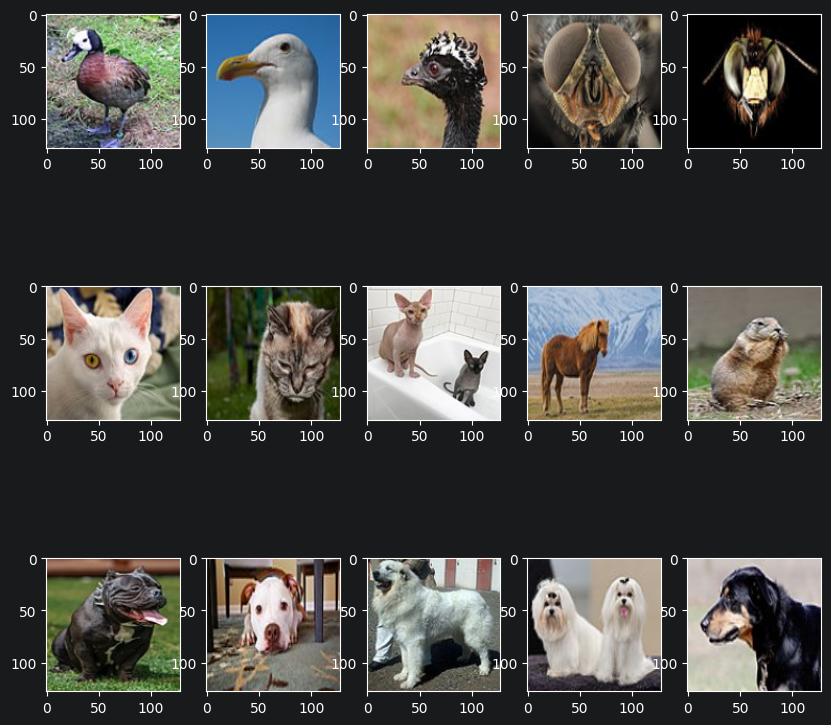

In [10]:
plot_images(3,5,animal_images)

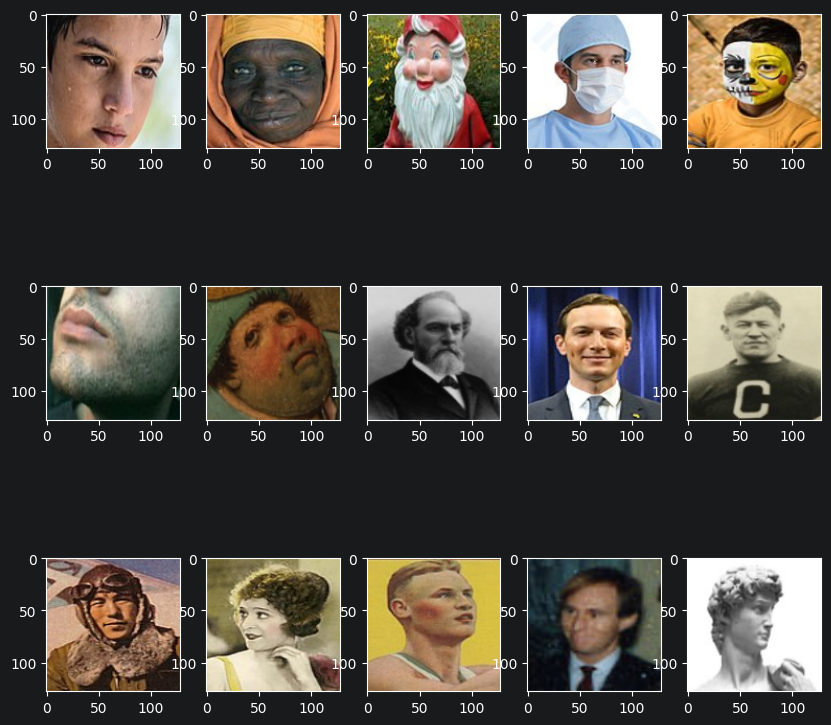

In [11]:
plot_images(3,5,face_images)

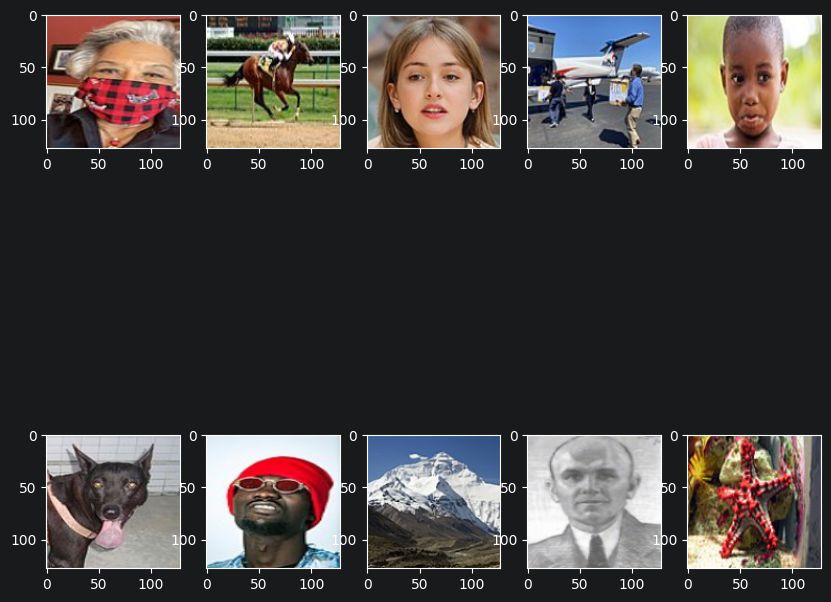

In [12]:
plot_images(2,5,test_images)

In [13]:
X = face_images + animal_images
y = [[1,0]] * len(face_images) + [[0,1]] * len(animal_images)

In [14]:
print(y)

[[1, 0], [1, 0], [1, 0], [1, 0], [1, 0], [1, 0], [1, 0], [1, 0], [1, 0], [1, 0], [1, 0], [1, 0], [1, 0], [1, 0], [1, 0], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1]]


In [15]:
X_train = tf.constant(X, dtype = tf.float32)
y_train = tf.constant(y, dtype = tf.float32)

In [16]:
print(X_train.shape)
print(y_train.shape)

(30, 128, 128, 3)
(30, 2)


In [17]:
X_train = X_train / 255.0

In [18]:
model = tf.keras.models.Sequential([
    tf.keras.Input((128,128,3)),
    tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2), padding='same'),
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2), padding='same'),
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2), padding='same'),
    tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2), padding='same'),
    tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2), padding='same'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dense(2,activation='softmax'),

])

In [19]:
model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [20]:
model.fit(X_train, y_train, epochs = 100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5000 - loss: 0.6931
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.4333 - loss: 0.6928
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.6667 - loss: 0.6876
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.6333 - loss: 0.6832
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.7000 - loss: 0.6724
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.8000 - loss: 0.6574
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.7333 - loss: 0.6378
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.7333 - loss: 0.6126
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.7333 - loss: 0.5745
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.7333 - loss: 0.5562
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.6667 - loss: 0.5614
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.

In [21]:
X_test = tf.constant(test_images, dtype = tf.float32)

In [22]:
X_test = X_test / 255.0

In [23]:
y_predict = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step


In [24]:
print(np.round(y_predict))

[[1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]]


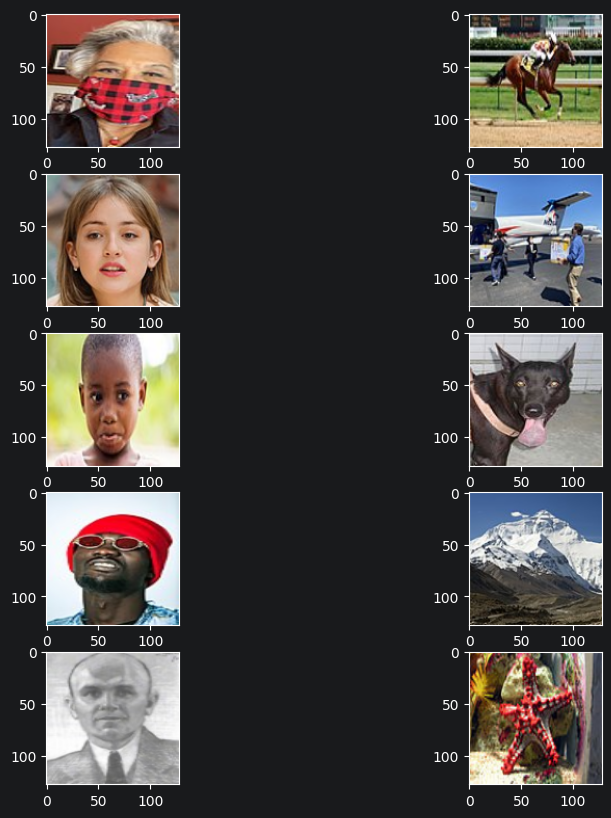

In [27]:

plot_images(5, 2, test_images)